Using device: cpu
Loaded 14552 beats | normal=4046  abnormal=10506
Class weights (normal, abnormal): [1.7983757257461548, 0.6925482749938965]
Epoch 01/30 | train_loss=0.4454 | val_loss=0.9659 | val_acc=0.5186 | val_f1=0.5026 | val_auc=0.9453
Epoch 02/30 | train_loss=0.2814 | val_loss=0.4073 | val_acc=0.8814 | val_f1=0.9236 | val_auc=0.9688
Epoch 03/30 | train_loss=0.2338 | val_loss=0.5647 | val_acc=0.8461 | val_f1=0.9037 | val_auc=0.9798
Epoch 04/30 | train_loss=0.2125 | val_loss=0.6038 | val_acc=0.6789 | val_f1=0.7154 | val_auc=0.9796
Epoch 05/30 | train_loss=0.1946 | val_loss=0.2670 | val_acc=0.8502 | val_f1=0.8850 | val_auc=0.9812
Epoch 06/30 | train_loss=0.1897 | val_loss=0.1445 | val_acc=0.9395 | val_f1=0.9568 | val_auc=0.9882
Epoch 07/30 | train_loss=0.1655 | val_loss=0.1387 | val_acc=0.9638 | val_f1=0.9751 | val_auc=0.9899
Epoch 08/30 | train_loss=0.1695 | val_loss=0.1724 | val_acc=0.9290 | val_f1=0.9494 | val_auc=0.9823
Epoch 09/30 | train_loss=0.1494 | val_loss=1.0159 | val_ac

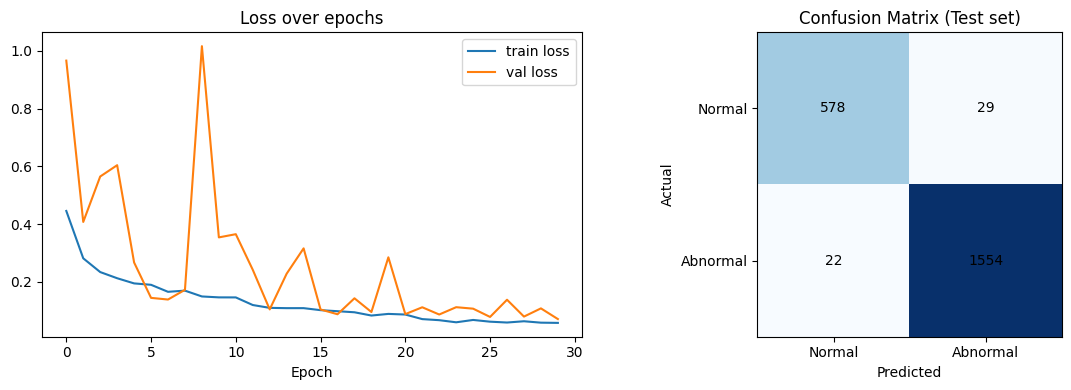

In [4]:
"""
ECG Abnormality Classification — PTB Diagnostic ECG Database
==============================================================
PyTorch reimplementation (CNN-based) of the classic "Abnormal Heartbeat
Classification" idea (originally a Keras/TensorFlow tutorial by Gabriel Atkin).

Expected input files (Kaggle "ECG Heartbeat Categorization Dataset" format,
which is the pre-segmented PTBDB release — 188 columns: 187 signal samples
+ 1 label column, no header):

    ptbdb_normal.csv
    ptbdb_abnormal.csv

If you're using the raw PhysioNet .dat/.hea signals instead, you'll need a
different loader (ask me — happy to add one using the `wfdb` package).

--------------------------------------------------------------------------
WHY A CNN, NOT AN RNN/LSTM? (time-series note, since you flagged this)
--------------------------------------------------------------------------
ECG heartbeats here are FIXED-LENGTH (187 points), already segmented and
aligned around one beat. That's the key fact that decides the architecture:

- A 1D CNN slides small filters along the beat and learns local waveform
  shapes (the P-wave, QRS complex, T-wave, ST segment) regardless of where
  exactly they sit in the window. That's exactly the kind of pattern that
  distinguishes a normal beat from an abnormal one — so CNNs are the
  standard, best-performing choice for this exact dataset in the literature.
- An LSTM/GRU (true "time series" modeling) shines when you care about
  long-range temporal dependencies across a variable-length sequence — e.g.
  classifying an arrhythmia over many consecutive beats, or working with
  raw un-segmented signals of varying length. For single fixed-length beats,
  it usually performs worse and trains much slower than a CNN.

I've included an OPTIONAL CNN+BiLSTM hybrid class at the bottom
(`CNNLSTMClassifier`) that you can swap in with one line, in case you want
to experiment with the RNN angle for your write-up/comparison section —
that's a nice thing to include in a "primary project" report (justify your
architecture choice empirically, not just by assumption).

--------------------------------------------------------------------------
HOW TO RUN
--------------------------------------------------------------------------
1. Download ptbdb_normal.csv and ptbdb_abnormal.csv, put them next to this
   script (or edit DATA_DIR below).
2. pip install torch numpy pandas scikit-learn matplotlib --break-system-packages
3. python ecg_classifier.py
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# 0. CONFIG
# --------------------------------------------------------------------------
DATA_DIR = "."                 # folder containing the two CSVs
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)


# --------------------------------------------------------------------------
# 1. DATA LOADING
# --------------------------------------------------------------------------
def load_ptbdb(data_dir):
    """Loads ptbdb_normal.csv + ptbdb_abnormal.csv into one array.
    Returns X: (N, 187) float32, y: (N,) int64  [0 = normal, 1 = abnormal]
    """
    normal_path = os.path.join(data_dir, "ptbdb_normal.csv")
    abnormal_path = os.path.join(data_dir, "ptbdb_abnormal.csv")

    df_normal = pd.read_csv(normal_path, header=None)
    df_abnormal = pd.read_csv(abnormal_path, header=None)

    df = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)

    X = df.iloc[:, :-1].values.astype(np.float32)   # 187 signal points
    y = df.iloc[:, -1].values.astype(np.int64)       # label column (0/1)
    return X, y


class ECGDataset(Dataset):
    """Wraps ECG beats as (1, 187) tensors — the '1' is the channel
    dimension Conv1d expects (like grayscale channel for images)."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 187)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# --------------------------------------------------------------------------
# 2. MODEL — 1D CNN (primary / recommended)
# --------------------------------------------------------------------------
class ECGCNNClassifier(nn.Module):
    """Simple, effective 1D CNN for fixed-length ECG beat classification.

    Each conv block: Conv1d -> BatchNorm -> ReLU -> MaxPool
    This progressively shrinks the 187-length signal while learning
    increasingly abstract waveform features.
    """

    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),                          # 187 -> 93
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),                          # 93 -> 46
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                  # global pool -> 128 x 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.classifier(x)


# --------------------------------------------------------------------------
# 2b. OPTIONAL — CNN + BiLSTM hybrid (for the "TSA" comparison angle)
# --------------------------------------------------------------------------
class CNNLSTMClassifier(nn.Module):
    """CNN extracts local waveform features, BiLSTM models how those
    features evolve across the beat. Use this if you want to include a
    'does explicit temporal modeling help here?' experiment in your report.
    """

    def __init__(self, num_classes=2, hidden_size=64, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(
            input_size=32, hidden_size=hidden_size,
            num_layers=1, batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x)                 # (B, 32, L)
        x = x.permute(0, 2, 1)          # (B, L, 32) -- LSTM wants (B, seq, features)
        out, (h_n, c_n) = self.lstm(x)
        # concat final forward + backward hidden states
        h_cat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        return self.classifier(h_cat)


# --------------------------------------------------------------------------
# 3. TRAIN / EVAL LOOPS
# --------------------------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),      # important: catching abnormal beats
        "f1": f1_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs),
    }
    return metrics, all_preds, all_labels


# --------------------------------------------------------------------------
# 4. MAIN
# --------------------------------------------------------------------------
def main():
    print(f"Using device: {DEVICE}")

    X, y = load_ptbdb(DATA_DIR)
    print(f"Loaded {len(X)} beats | normal={np.sum(y == 0)}  abnormal={np.sum(y == 1)}")

    # Stratified split keeps the normal/abnormal ratio consistent across sets
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )

    train_ds = ECGDataset(X_train, y_train)
    val_ds = ECGDataset(X_val, y_val)
    test_ds = ECGDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    # Handle class imbalance (PTBDB has more abnormal than normal beats,
    # but this makes the code robust either way) by weighting the loss
    class_counts = np.bincount(y_train)
    class_weights = torch.tensor(
        [len(y_train) / (2.0 * c) for c in class_counts], dtype=torch.float32
    ).to(DEVICE)
    print(f"Class weights (normal, abnormal): {class_weights.tolist()}")

    model = ECGCNNClassifier().to(DEVICE)
    # To try the hybrid model instead, just swap the line above for:
    # model = CNNLSTMClassifier().to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_f1 = 0.0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | val_auc={val_metrics['auc']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), "best_ecg_model.pt")

    # ---- Final test evaluation using the best checkpoint ----
    model.load_state_dict(torch.load("best_ecg_model.pt"))
    test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion)

    print("\n=== FINAL TEST RESULTS ===")
    for k, v in test_metrics.items():
        print(f"{k:>10}: {v:.4f}")

    print("\nClassification report:")
    print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

    cm = confusion_matrix(test_labels, test_preds)
    print("Confusion matrix:")
    print(cm)

    # ---- Plots ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_title("Loss over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].imshow(cm, cmap="Blues")
    axes[1].set_title("Confusion Matrix (Test set)")
    axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Normal", "Abnormal"])
    axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["Normal", "Abnormal"])
    for i in range(2):
        for j in range(2):
            axes[1].text(j, i, cm[i, j], ha="center", va="center", color="black")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

    plt.tight_layout()
   


if __name__ == "__main__":
    main()


Starting Training...
Epoch 1/30 | Loss: 0.5074
Epoch 2/30 | Loss: 0.3971
Epoch 3/30 | Loss: 0.3701
Epoch 4/30 | Loss: 0.3553
Epoch 5/30 | Loss: 0.3405
Epoch 6/30 | Loss: 0.3219
Epoch 7/30 | Loss: 0.3044
Epoch 8/30 | Loss: 0.2848
Epoch 9/30 | Loss: 0.2635
Epoch 10/30 | Loss: 0.2414
Epoch 11/30 | Loss: 0.2190
Epoch 12/30 | Loss: 0.2001
Epoch 13/30 | Loss: 0.1798
Epoch 14/30 | Loss: 0.1652
Epoch 15/30 | Loss: 0.1564
Epoch 16/30 | Loss: 0.1434
Epoch 17/30 | Loss: 0.1315
Epoch 18/30 | Loss: 0.1224
Epoch 19/30 | Loss: 0.1147
Epoch 20/30 | Loss: 0.1053
Epoch 21/30 | Loss: 0.0978
Epoch 22/30 | Loss: 0.0915
Epoch 23/30 | Loss: 0.0862
Epoch 24/30 | Loss: 0.0813
Epoch 25/30 | Loss: 0.0712
Epoch 26/30 | Loss: 0.0683
Epoch 27/30 | Loss: 0.0652
Epoch 28/30 | Loss: 0.0588
Epoch 29/30 | Loss: 0.0550
Epoch 30/30 | Loss: 0.0525

Final Test Accuracy: 97.94%
Confusion Matrix:
 [[ 791   43]
 [  17 2060]]


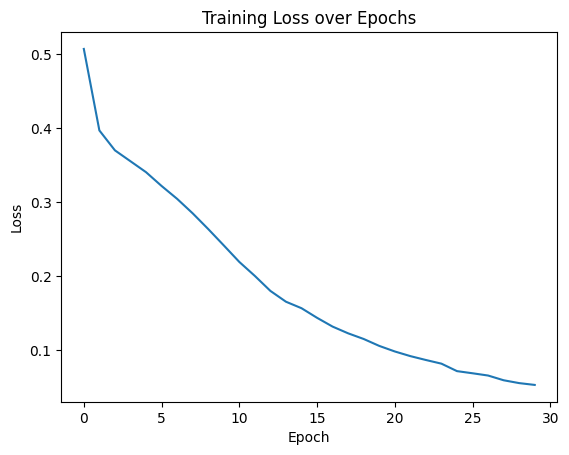

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
# Load the CSV files
df_normal = pd.read_csv("ptbdb_normal.csv", header=None)
df_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

# Combine and separate features (X) from labels (y)
df = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.int64)

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert arrays to PyTorch Tensors. 
# The unsqueeze(1) adds a "channel" dimension needed for 1D Convolutions.
X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_test_t = torch.tensor(y_test)

# Use PyTorch's built-in TensorDataset instead of writing a custom class
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

# ---------------------------------------------------------
# 2. DEFINE THE NEURAL NETWORK
# ---------------------------------------------------------
class SimpleECGModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature Extractor: Finds patterns in the waveform
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Classifier: Uses the found patterns to make a decision
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 43, 64), # 43 is the length of the signal after two MaxPools
            nn.ReLU(),
            nn.Linear(64, 2)        # 2 outputs: Normal (0) or Abnormal (1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleECGModel()

# ---------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.CrossEntropyLoss()

epochs = 30
train_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()            # Clear old gradients
        predictions = model(batch_X)     # Forward pass
        loss = loss_function(predictions, batch_y) # Calculate error
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Update weights
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# ---------------------------------------------------------
# 4. EVALUATION
# ---------------------------------------------------------
model.eval() # Set model to evaluation mode
all_preds = []

with torch.no_grad(): # Turn off gradient tracking for testing
    for batch_X, _ in test_loader:
        predictions = model(batch_X)
        # Get the index of the highest probability (0 or 1)
        predicted_classes = torch.argmax(predictions, dim=1)
        all_preds.extend(predicted_classes.numpy())

# Calculate Metrics
acc = accuracy_score(y_test, all_preds)
cm = confusion_matrix(y_test, all_preds)

print(f"\nFinal Test Accuracy: {acc * 100:.2f}%")
print("Confusion Matrix:\n", cm)

# Plot Training Loss
plt.plot(train_losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Starting Training...
Epoch 1/30 | Train Loss: 0.5828 | Val Loss: 0.5190 -> Model Saved
Epoch 2/30 | Train Loss: 0.4508 | Val Loss: 0.4263 -> Model Saved
Epoch 3/30 | Train Loss: 0.4044 | Val Loss: 0.3909 -> Model Saved
Epoch 4/30 | Train Loss: 0.3747 | Val Loss: 0.3724 -> Model Saved
Epoch 5/30 | Train Loss: 0.3497 | Val Loss: 0.3382 -> Model Saved
Epoch 6/30 | Train Loss: 0.3288 | Val Loss: 0.3313 -> Model Saved
Epoch 7/30 | Train Loss: 0.3066 | Val Loss: 0.3022 -> Model Saved
Epoch 8/30 | Train Loss: 0.2831 | Val Loss: 0.2750 -> Model Saved
Epoch 9/30 | Train Loss: 0.2635 | Val Loss: 0.2583 -> Model Saved
Epoch 10/30 | Train Loss: 0.2395 | Val Loss: 0.2492 -> Model Saved
Epoch 11/30 | Train Loss: 0.2206 | Val Loss: 0.2305 -> Model Saved
Epoch 12/30 | Train Loss: 0.2085 | Val Loss: 0.2783
Epoch 13/30 | Train Loss: 0.2139 | Val Loss: 0.2030 -> Model Saved
Epoch 14/30 | Train Loss: 0.1867 | Val Loss: 0.1813 -> Model Saved
Epoch 15/30 | Train Loss: 0.1779 | Val Loss: 0.1750 -> Model Save

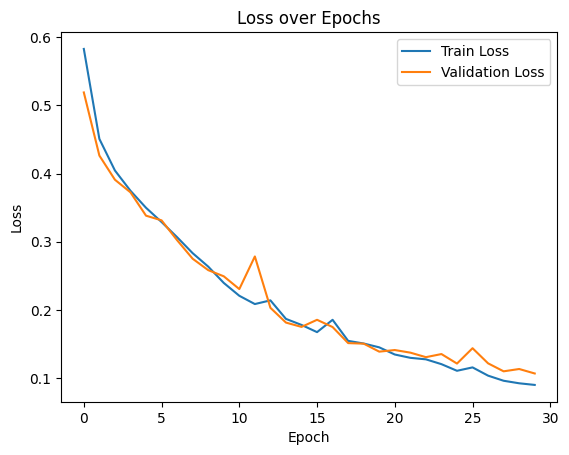

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
df_normal = pd.read_csv("ptbdb_normal.csv", header=None)
df_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

df = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.int64)

# TUNING: Stratified split ensures the exact ratio of normal/abnormal beats is maintained
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_val_t = torch.tensor(X_val).unsqueeze(1)
y_val_t = torch.tensor(y_val)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_test_t = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

# ---------------------------------------------------------
# 2. DEFINE THE NEURAL NETWORK
# ---------------------------------------------------------
class SimpleECGModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 43, 64), 
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleECGModel()

# ---------------------------------------------------------
# 3. TRAINING & VALIDATION LOOP
# ---------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TUNING: Penalize false positives by weighting the minority "Normal" class higher
class_counts = np.bincount(y_train)
weights = torch.tensor([len(y_train) / class_counts[0], len(y_train) / class_counts[1]], dtype=torch.float32)
loss_function = nn.CrossEntropyLoss(weight=weights)

epochs = 30
train_losses, val_losses = [], []
best_val_loss = float('inf')

print("Starting Training...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = loss_function(predictions, batch_y)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}", end="")
    
    # TUNING: Save the model only when validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print(" -> Model Saved")
    else:
        print()

# ---------------------------------------------------------
# 4. EVALUATION
# ---------------------------------------------------------
# TUNING: Load the optimal weights from the checkpoint before testing
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()
all_preds = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        predictions = model(batch_X)
        predicted_classes = torch.argmax(predictions, dim=1)
        all_preds.extend(predicted_classes.numpy())

acc = accuracy_score(y_test, all_preds)
cm = confusion_matrix(y_test, all_preds)

print(f"\nFinal Test Accuracy: {acc * 100:.2f}%")
print("Confusion Matrix:\n", cm)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Starting Training...
Epoch 1/40 | Train Loss: 0.4374 | Val Loss: 0.3090 -> Model Saved
Epoch 2/40 | Train Loss: 0.2662 | Val Loss: 0.2026 -> Model Saved
Epoch 3/40 | Train Loss: 0.2149 | Val Loss: 0.1995 -> Model Saved
Epoch 4/40 | Train Loss: 0.1843 | Val Loss: 0.2089
Epoch 5/40 | Train Loss: 0.1544 | Val Loss: 0.1594 -> Model Saved
Epoch 6/40 | Train Loss: 0.1404 | Val Loss: 0.1258 -> Model Saved
Epoch 7/40 | Train Loss: 0.1335 | Val Loss: 0.1459
Epoch 8/40 | Train Loss: 0.1161 | Val Loss: 0.1011 -> Model Saved
Epoch 9/40 | Train Loss: 0.1009 | Val Loss: 0.1659
Epoch 10/40 | Train Loss: 0.0877 | Val Loss: 0.0763 -> Model Saved
Epoch 11/40 | Train Loss: 0.0920 | Val Loss: 0.1333
Epoch 12/40 | Train Loss: 0.0741 | Val Loss: 0.0801
Epoch 13/40 | Train Loss: 0.0732 | Val Loss: 0.0985
Epoch 14/40 | Train Loss: 0.0813 | Val Loss: 0.0720 -> Model Saved
Epoch 15/40 | Train Loss: 0.0644 | Val Loss: 0.1051
Epoch 16/40 | Train Loss: 0.0653 | Val Loss: 0.0747
Epoch 17/40 | Train Loss: 0.0583 | V

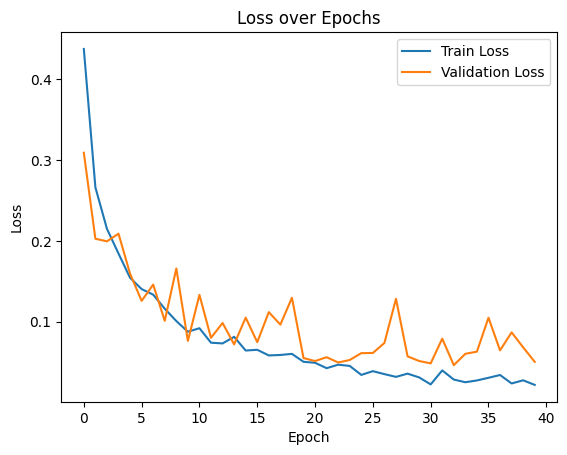

In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ---------------------------------------------------------
df_normal = pd.read_csv("ptbdb_normal.csv", header=None)
df_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

df = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.int64)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_val_t = torch.tensor(X_val).unsqueeze(1)
y_val_t = torch.tensor(y_val)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_test_t = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

# ---------------------------------------------------------
# 2. DEFINE THE NEURAL NETWORK (Upgraded Architecture)
# ---------------------------------------------------------
class SimpleECGModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5),
            nn.BatchNorm1d(16), # NEW: Normalizes signals to keep gradients stable
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5),
            nn.BatchNorm1d(32), # NEW: Normalizes signals to keep gradients stable
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),    # NEW: Randomly disables 40% of neurons to prevent overfitting
            nn.Linear(32 * 43, 64), 
            nn.ReLU(),
            nn.Dropout(0.2),    # NEW: Randomly disables 20% of neurons
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleECGModel()

# ---------------------------------------------------------
# 3. TRAINING & VALIDATION LOOP
# ---------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TUNING: Normalized "balanced" weights to prevent overly punishing the Abnormal class
class_counts = np.bincount(y_train)
total_samples = len(y_train)
balanced_weights = [total_samples / (2.0 * class_counts[0]), 
                    total_samples / (2.0 * class_counts[1])]
weights = torch.tensor(balanced_weights, dtype=torch.float32)

loss_function = nn.CrossEntropyLoss(weight=weights)

epochs = 40 # Increased to give the Dropout network time to learn
train_losses, val_losses = [], []
best_val_loss = float('inf')

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = loss_function(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = loss_function(predictions, batch_y)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}", end="")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print(" -> Model Saved")
    else:
        print()

# ---------------------------------------------------------
# 4. EVALUATION
# ---------------------------------------------------------
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
model.eval()
all_preds = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        predictions = model(batch_X)
        predicted_classes = torch.argmax(predictions, dim=1)
        all_preds.extend(predicted_classes.numpy())

acc = accuracy_score(y_test, all_preds)
cm = confusion_matrix(y_test, all_preds)

print(f"\nFinal Test Accuracy: {acc * 100:.2f}%")
print("Confusion Matrix:\n", cm)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
len(df_abnormal)+len(df_normal)

14552